# NYC Public School SAT Performance Analysis

## Resume

This project analyzes SAT performance data from New York City public schools to identify high-performing schools in mathematics, determine the top schools based on combined SAT scores, and evaluate score variability across boroughs.

## Objetive

The goal of this analysis is to answer three key questions:

1. Which NYC public schools achieve outstanding mathematics performance?
2. Which schools have the highest combined SAT scores?
3. Which borough shows the greatest variability in SAT performance?

## Data Dictionary

| Column            | Data Type | Description                                                                                     |
| ----------------- | --------- | ----------------------------------------------------------------------------------------------- |
| `school_name`     | string    | Name of the public school.                                                                      |
| `borough`         | string    | NYC borough where the school is located (Bronx, Brooklyn, Manhattan, Queens, or Staten Island). |
| `building_code`   | string    | Unique identifier assigned to the school building.                                              |
| `average_math`    | integer   | Average SAT Mathematics score.                                                                  |
| `average_reading` | integer   | Average SAT Critical Reading score.                                                             |
| `average_writing` | integer   | Average SAT Writing score.                                                                      |
| `percent_tested`  | float     | Percentage of students who took the SAT exam.                                                   |
| `total_SAT`*      | integer   | Calculated field representing the sum of Mathematics, Reading, and Writing SAT scores.          |


## Data Preparation

In [11]:
# Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
schools = pd.read_csv("../data/raw/NYC_public_school_exam_Scores.csv")
schools.head()

,school_name,borough,building_code,average_math,average_reading,average_writing,percent_tested
0,"New Explorations into Science, Technology and ...",Manhattan,M022,657,601,601,NaN
1,Essex Street Academy,Manhattan,M445,395,411,387,78.9
2,Lower Manhattan Arts Academy,Manhattan,M445,418,428,415,65.1
3,High School for Dual Language and Asian Studies,Manhattan,M445,613,453,463,95.9
4,Henry Street School for International Studies,Manhattan,M056,410,406,381,59.7


## Data Preparation

In [12]:
# Calculate the combined SAT score for each school
schools["total_SAT"] = (
    schools["average_math"]
    + schools["average_reading"]
    + schools["average_writing"]
)

## Schools that achieved at least 80% of the maximum SAT math score

In [13]:
# Identify the best math schools based on average math scores
best_math_schools = (
    schools.loc[
        schools["average_math"] >= 640,
        ["school_name", "average_math"]
    ]
    .sort_values("average_math", ascending=False)
)

# Display the best math schools
print(f"Best Math Schools:\n{best_math_schools}")

Best Math Schools:
                                           school_name  average_math
88                              Stuyvesant High School           754
170                       Bronx High School of Science           714
93                 Staten Island Technical High School           711
365  Queens High School for the Sciences at York Co...           701
68   High School for Mathematics, Science, and Engi...           683
280                     Brooklyn Technical High School           682
333                        Townsend Harris High School           680
174  High School of American Studies at Lehman College           669
0    New Explorations into Science, Technology and ...           657
45                       Eleanor Roosevelt High School           641


## Top ten schools with the highest combined SAT scores

In [14]:
# Rank schools by total SAT score
top_10_schools = (
    schools[["school_name", "total_SAT"]]
    .sort_values("total_SAT", ascending=False)
    .head(10)
)

# Display the top 10 schools by total SAT score
print(f"Top 10 Schools by Total SAT Score:\n{top_10_schools}")

Top 10 Schools by Total SAT Score:
                                           school_name  total_SAT
88                              Stuyvesant High School       2144
170                       Bronx High School of Science       2041
93                 Staten Island Technical High School       2041
174  High School of American Studies at Lehman College       2013
333                        Townsend Harris High School       1981
365  Queens High School for the Sciences at York Co...       1947
5                       Bard High School Early College       1914
280                     Brooklyn Technical High School       1896
45                       Eleanor Roosevelt High School       1889
68   High School for Mathematics, Science, and Engi...       1889


### Chart 1

<Figure size 1000x600 with 0 Axes>

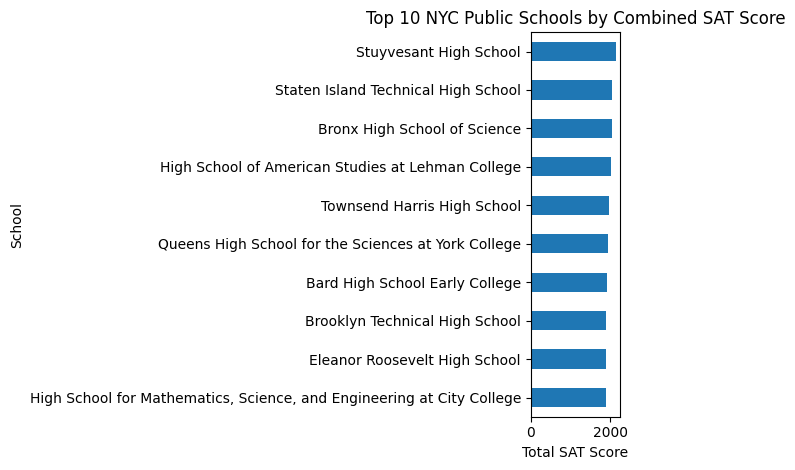

In [15]:
# The chart ranks the ten highest-performing schools based on their combined SAT scores.
plt.figure(figsize=(10, 6))

top_10_schools.sort_values("total_SAT").plot(
    kind="barh",
    x="school_name",
    y="total_SAT",
    legend=False
)

plt.title("Top 10 NYC Public Schools by Combined SAT Score")
plt.xlabel("Total SAT Score")
plt.ylabel("School")
plt.tight_layout()
plt.show()

## SAT performance statistics for each borough

In [16]:
# Analyze the distribution of total SAT scores across boroughs
borough_stats = (
    schools.groupby("borough")
    .agg(
        num_schools=("school_name", "count"),
        average_SAT=("total_SAT", "mean"),
        std_SAT=("total_SAT", "std")
    )
    .round(2)
)

# Display the SAT score distribution by borough
print(f"SAT Score Distribution by Borough:\n{borough_stats}")

SAT Score Distribution by Borough:
               num_schools  average_SAT  std_SAT
borough                                         
Bronx                   98      1202.72   150.39
Brooklyn               109      1230.26   154.87
Manhattan               89      1340.13   230.29
Queens                  69      1345.48   195.25
Staten Island           10      1439.00   222.30


### Chart 2

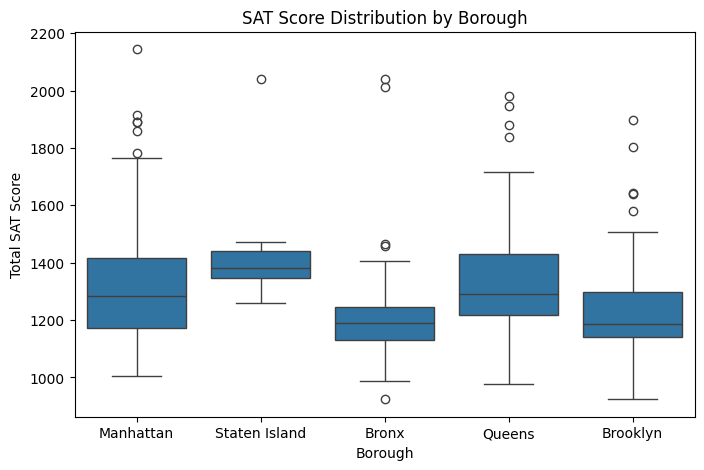

In [17]:
# The boxplot illustrates how SAT performance varies across NYC boroughs and highlights differences in score dispersion.
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=schools,
    x="borough",
    y="total_SAT"
)

plt.title("SAT Score Distribution by Borough")
plt.xlabel("Borough")
plt.ylabel("Total SAT Score")
plt.show()

In [18]:
# Identify the borough with the greatest SAT score variability
largest_std_dev = (
    borough_stats
    .sort_values("std_SAT", ascending=False)
    .head(1)
    .reset_index()
)

# Display the borough with the greatest SAT score variability
print(f"Borough with Greatest SAT Score Variability:\n{largest_std_dev}")

Borough with Greatest SAT Score Variability:
     borough  num_schools  average_SAT  std_SAT
0  Manhattan           89      1340.13   230.29


## Key Findings

- Several NYC public schools exceeded the mathematics excellence benchmark of 640 points, demonstrating strong performance in SAT mathematics.
- Stuyvesant High School achieved the highest combined SAT score, closely followed by other specialized and highly selective public schools.
- The top-performing schools all recorded combined SAT scores above 2,000 points, indicating consistently strong results across mathematics, reading, and writing.
- SAT performance varies across boroughs, with Queens and Manhattan showing the widest score distributions.
- Manhattan recorded the highest overall SAT score in the dataset, while several boroughs contained notable high-performing outlier schools.

## Conclusion

This analysis identified schools with outstanding mathematics performance, ranked the highest-performing schools based on combined SAT scores, and examined score variability across NYC boroughs. The results highlight the presence of several high-achieving schools across the city and reveal differences in SAT score distributions among boroughs, providing a concise overview of academic performance in NYC public schools.